In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from pykalman import KalmanFilter

from sklearn.linear_model import LinearRegression

In [3]:
hist_df=pd.read_csv("data.csv")
test_data=hist_df[hist_df["day"]>55]
hist_df=hist_df[hist_df["day"]<=55]
hist_df.tail()


,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
21500,386,55,386,122.83,263.02,368.20,227.26,189.91,262.11
21501,387,55,387,122.78,262.56,367.85,227.70,189.99,262.04
21502,388,55,388,122.78,262.42,367.72,227.39,190.41,261.99
21503,389,55,389,122.88,262.93,368.79,227.09,190.65,262.37
21504,390,55,390,122.93,263.58,368.97,226.14,190.39,262.27


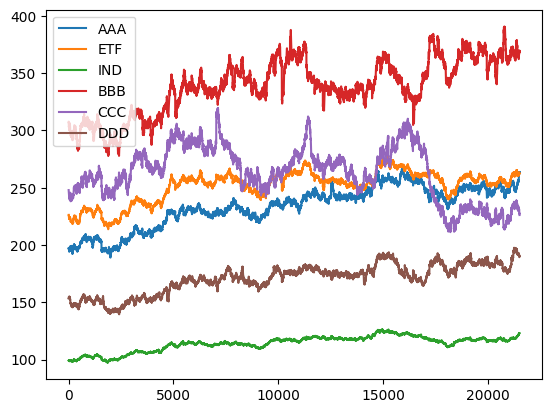

In [4]:
stock_codes=["AAA","ETF","IND","BBB","CCC","DDD"]
#fig, ax = plt.subplots(figsize=(15, 5))
#balance= pd.Series(train_data['resp']).cumsum()
#ax.set_xlabel ("Trade", fontsize=18)
#ax.set_ylabel ("Cumulative resp", fontsize=18);
for name in stock_codes:
    plt.plot(hist_df.index,hist_df[name],label=name)

plt.legend()


In [5]:
all=[]
for i in range(len(stock_codes)):
    pricediff = None
    for j in range(i+1, len(stock_codes)):
        stock_code1 = stock_codes[i]
        stock_code2 = stock_codes[j]
        
        data1 = df[stock_code1]
        data2 = df[stock_code2]

        result=pd.DataFrame()
        result[stock_code1]=data1
        result[stock_code2]=data2
        #print(result.head())
        
        cj = coint_johansen(result[[stock_code1, stock_code2]], det_order=1, k_ar_diff=1)
        
        if cj.trace_stat[0] > cj.trace_stat_crit_vals[0][2]:
            all.append((cj.trace_stat[0],(stock_code1,stock_code2)))
            #print(cj.trace_stat[0],cj.trace_stat_crit_vals[0][2])
            #print(f"Cointegration found for {stock_code1} and {stock_code2}")
            pricediff = result[[stock_code1, stock_code2]] @ cj.evec[0]

all.sort(reverse=True)
print(all)
print(len(all))
#why does everyone has pairtrading potential

NameError: name 'df' is not defined

In [6]:
#test 5 days rolling average good pairs
corr_table = pd.DataFrame(index=stock_codes, columns=stock_codes)

for i in range(6): 
    for j in range(6): 
        corr_table.loc[stock_codes[i],stock_codes[j]]=0

for times in range(1,54):
    df=hist_df[hist_df['day']>=times]
    df=df[df['day']<=times+2]
    for i in range(len(stock_codes)):
        for j in range(i+1,len(stock_codes)):
            corr_value = df[stock_codes[i]].corr(df[stock_codes[j]])
            corr_table.loc[stock_codes[i], stock_codes[j]] += corr_value/55
            corr_table.loc[stock_codes[j], stock_codes[i]] += corr_value/55

for code in stock_codes:
    corr_table.loc[code, code] = 1.0

print(corr_table)

          AAA       ETF       IND       BBB       CCC       DDD
AAA       1.0  0.597793  0.759245  0.362029   0.35987  0.360652
ETF  0.597793       1.0  0.654127  0.737556  0.606273   0.62738
IND  0.759245  0.654127       1.0   0.46847  0.341041  0.492432
BBB  0.362029  0.737556   0.46847       1.0  0.162278  0.567214
CCC   0.35987  0.606273  0.341041  0.162278       1.0  0.228542
DDD  0.360652   0.62738  0.492432  0.567214  0.228542       1.0


In [8]:

def KFSmoother(prices, initial_state = 0.0):
    """Estimate rolling mean"""
    
    kf = KalmanFilter(transition_matrices=np.eye(1),
                      observation_matrices=np.eye(1),
                      initial_state_mean=initial_state,
                      initial_state_covariance=1,
                      observation_covariance=1,
                      transition_covariance=.05)

    state_means, _ = kf.filter(prices.values)
    return pd.Series(state_means.flatten(),
                     index=prices.index)

def KFHedgeRatio(x, y):
    """Estimate Hedge Ratio"""
    delta = 1e-3
    trans_cov = delta / (1 - delta) * np.eye(2)
    obs_mat = np.expand_dims(np.vstack([[x], [np.ones(len(x))]]).T, axis=1)

    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2,
                      initial_state_mean=[0, 0],
                      initial_state_covariance=np.ones((2, 2)),
                      transition_matrices=np.eye(2),
                      observation_matrices=obs_mat,
                      observation_covariance=2,
                      transition_covariance=trans_cov)

    state_means, _ = kf.filter(y.values)
    return -state_means

In [10]:
filtered_train = {}
for security in stock_codes:
    temp_filter1 = KFSmoother(hist_df[security], hist_df[security][0])
    temp_filter2 = KFSmoother(hist_df[security])
    filtered_train[security] = temp_filter1


In [11]:
filtered_train["AAA"].shape
new_df=pd.concat(filtered_train.values(),axis=1)
new_df.columns=filtered_train.keys()
new_df=pd.concat([hist_df["day"],new_df],axis=1)

filtered_train=new_df
filtered_train

,day,AAA,ETF,IND,BBB,CCC,DDD
0,1,196.870000,226.260000,99.130000,307.090000,247.920000,153.150000
1,1,196.795484,226.157097,99.133548,306.830968,247.838387,153.160645
2,1,196.805431,226.065718,99.144053,306.847979,247.464225,153.148932
3,1,196.783841,226.076908,99.105122,307.055715,247.296367,153.169419
4,1,196.685353,225.956794,99.066752,306.798778,247.136875,153.199762
...,...,...,...,...,...,...,...
21500,55,262.870220,262.421902,122.818702,368.758443,227.978310,190.031921
21501,55,262.808176,262.345522,122.810962,368.576754,227.922648,190.023537
21502,55,262.730541,262.274417,122.804769,368.405403,227.816119,190.100830
21503,55,262.770433,262.293534,122.819815,368.482323,227.670895,190.210664


In [23]:
#Do fitting for every 5 days

security1="ETF"
security2="BBB"


limdf1 = filtered_train[security1][(filtered_train["day"] >= 53)]
limdf2 = filtered_train[security2][(filtered_train["day"] >= 53)]

#limdf1.shape,limdf2.shape
linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(limdf1.values.reshape(-1,1), limdf2.values)
linear_model.intercept_,linear_model.coef_

(np.float64(95.46931822547003), array([1.05311287]))

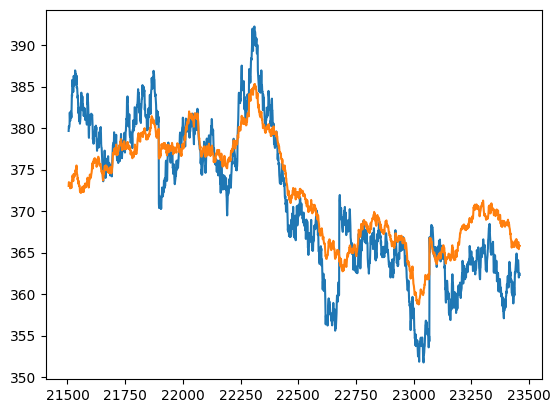

In [24]:
y_fit=linear_model.coef_*test_data[security1]+linear_model.intercept_
plt.plot(test_data[security2])
plt.plot(y_fit)
#test_data[security1]



(np.float64(4.31792969543484), np.float64(-1.0595512300584884))

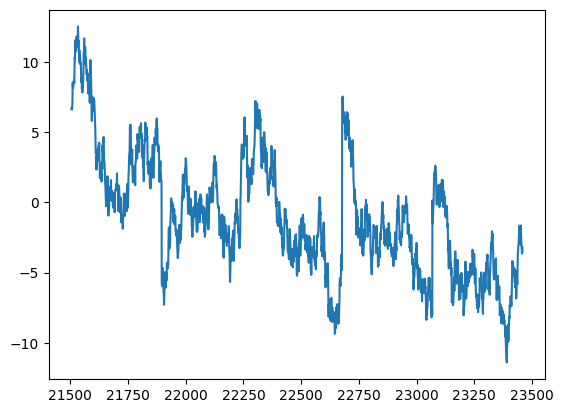

In [25]:
diff=test_data[security2]-y_fit
diff.plot()
diff.mean()
np.sqrt(diff.var()), diff.mean()